# tSNE

En este notebook vamos a utilizar tSNE para reducir la dimensionalidad de un dataset y compararlo al modelo [PCA](../PCA/).

### SETUP
Como siempre, instalamos e importamos librerias y generamos el dataset

In [5]:
!pip install -q numpy==2.2.0
!pip install -q pandas==2.2.3
!pip install -q matplotlib==3.9.3
!pip install -q plotly==5.24.1
!pip install -q --upgrade scikit-learn 
!pip install -q nbformat>=4.2.0

In [3]:
# Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import plotly.express as px
from sklearn.datasets import make_blobs

# Generamos "dataset"

# Definimos centroides
centers = [ [ 2, -6, -6],
            [-1,  9,  4],
            [-8,  7,  2],
            [ 4,  7,  9] ]

# Definimos desviacion estandar de los clusters
cluster_std=[1,1,2,3.5]

# Generamos blobs, obtenemos labels y data
X, labels_ = make_blobs(n_samples=500, centers=centers, n_features=3, cluster_std=cluster_std, random_state=42)

Una vez definido el dataset podemos visualizar la estructura resultante con un modelado 3D

In [9]:
# Creamos dataframe
df = pd.DataFrame(X, columns=['X', 'Y', 'Z'])

# Scatter plot 
fig = px.scatter_3d(df, x='X', y='Y', z='Z', color=labels_.astype(str) ,  opacity=0.7,  color_discrete_sequence=px.colors.qualitative.G10, title="Ploteo 3D de Dataset")

fig.update_traces(marker=dict(size=5, line=dict(width=1, color='black')), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800)  # Remove color bar, resize plot

fig.show()

### Preprocesamiento del Dataset
Logicamente no podemos utilizar el dataset en crudo, estandaricemos entonces nuestra información

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Creacion del modelo
Teniendo nuestro dataset estandarizado podemos crear el model tSNE y trabajar nuestra información

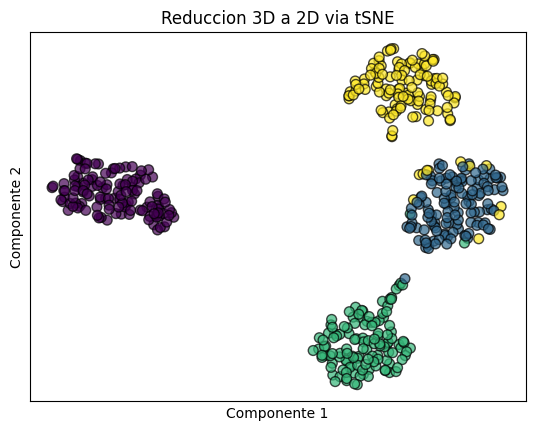

In [6]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax.set_title("Reduccion 3D a 2D via tSNE")
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

Podemos observar que la reducción aparentaria ser bastante exitosa, si bien tenemos un leve entrecruzamiento en el cluster azul, hay claramente un conjunto de clusters bien definidos. Comparemos entonces este metodo con PCA 

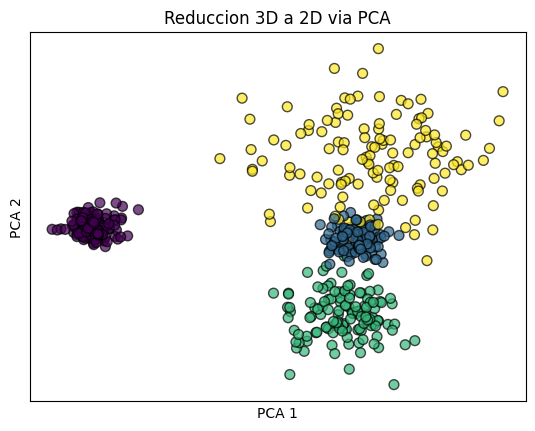

In [8]:
# Creamos modelo PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


fig = plt.figure()

# Ploteamos resultado pca
ax2 = fig.add_subplot(111)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax2.set_title("Reduccion 3D a 2D via PCA")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_xticks([])
ax2.set_yticks([])
plt.show()


En el modelo PCA , 2 clusters que previamente eran altamente densos ahora estan esparcidos en mayor escala y dejan poco lugar al cluster azul. Si bien dentro de todo podemos ver que la escala de separación entre clusters es relativamente similar entre modelos, la visualización aparentaria demostrar que tSNE tuvo mejores resultados.